In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [2]:
customer = pd.read_csv(r"Telco_Customer_Churn.csv")

In [3]:
customer.shape

(7043, 21)

In [4]:
customer.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
customer.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


# Customer gender count

In [6]:
customer['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

# Are senior citizens more at risk of churn

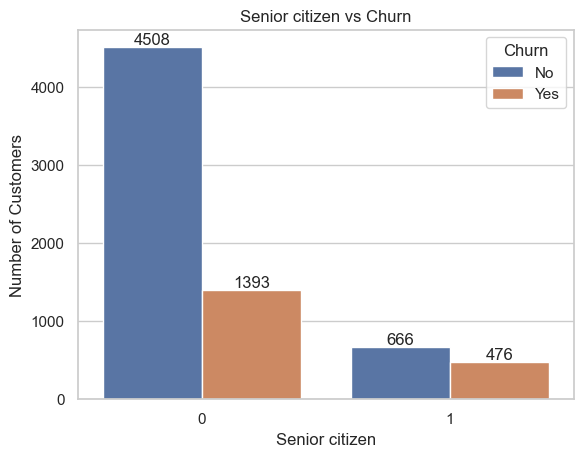

In [7]:
ax = sns.countplot(data=customer, x='SeniorCitizen', hue='Churn')

ax.set_title('Senior citizen vs Churn')
ax.set_xlabel('Senior citizen')
ax.set_ylabel('Number of Customers')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

- Senior citizens are more likely to churn

# Are month-to-month customers significantly more likely to churn than customers on long-term contracts

C:\Users\PAVANA HEBBAR\AppData\Local\Temp\ipykernel_1920\1847852784.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=contract_churn,x='Contract',y='ChurnRate',palette='Set2')


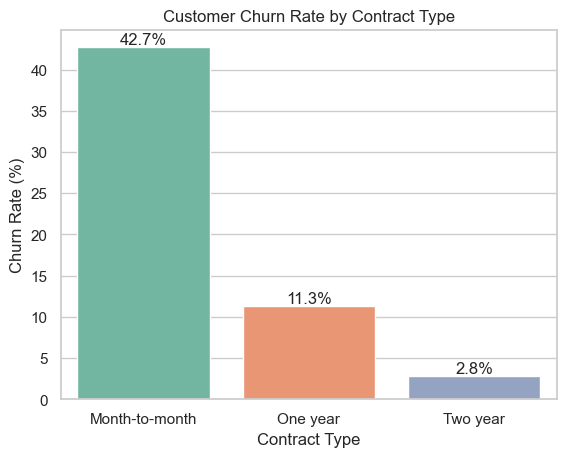

In [8]:
contract_churn = (
    customer.groupby('Contract')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='ChurnRate')
)

ax = sns.barplot(data=contract_churn,x='Contract',y='ChurnRate',palette='Set2')

ax.set_title('Customer Churn Rate by Contract Type')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

- Month-to-month customers have the highest churn rate at 42.7%, compared with 11.3% for one-year and only 2.8% for two-year contracts. This makes month-to-month customers the key segment for retention and potential long-term contract conversion.

# At what stage of the customer lifecycle is churn highest?

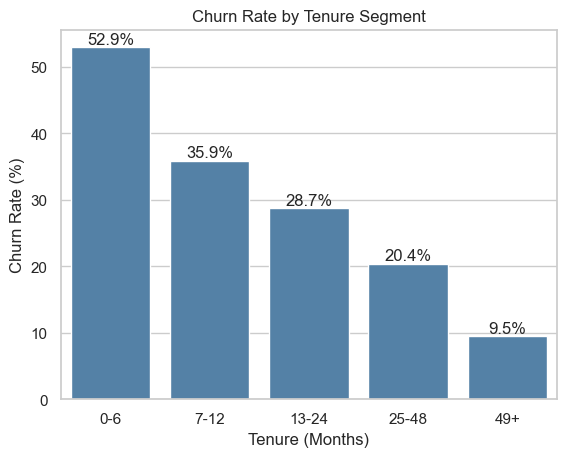

In [9]:
bins = [0, 6, 12, 24, 48, customer['tenure'].max()]
labels = ['0-6', '7-12', '13-24', '25-48', '49+']

customer['TenureGroup'] = pd.cut(customer['tenure'],bins=bins,labels=labels,include_lowest=True)

churn_rate = (customer.groupby('TenureGroup', observed=True)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index(name='ChurnRate'))

ax = sns.barplot(data=churn_rate,x='TenureGroup',y='ChurnRate',color='steelblue')

ax.set_title('Churn Rate by Tenure Segment')
ax.set_xlabel('Tenure (Months)')
ax.set_ylabel('Churn Rate (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

- Churn is highest among customers in their first 0–6 months (52.9%) and declines as tenure increases. This indicates that the early customer lifecycle, particularly the first six months, is the most critical period for retention efforts.

# Revenue at risk of churn

In [10]:
Churn_revenue = customer.loc[customer['Churn'] == 'Yes', 'MonthlyCharges'].sum()
print(f"Monthly Revenue at Risk: {Churn_revenue:.2f}")

Monthly Revenue at Risk: 139130.85


# Revenue at risk by Internet service

C:\Users\PAVANA HEBBAR\AppData\Local\Temp\ipykernel_1920\461581552.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=internet_revenue,x='InternetService',y='RevenueAtRisk',palette='Set2')


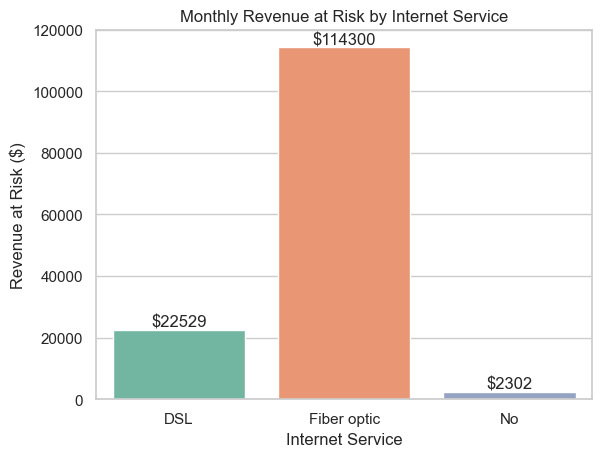

In [11]:
internet_revenue = (customer[customer['Churn'] == 'Yes'].groupby('InternetService', as_index=False)['MonthlyCharges'].sum().rename(columns={'MonthlyCharges':'RevenueAtRisk'}))

ax = sns.barplot(data=internet_revenue,x='InternetService',y='RevenueAtRisk',palette='Set2')

ax.set_title('Monthly Revenue at Risk by Internet Service')
ax.set_xlabel('Internet Service')
ax.set_ylabel('Revenue at Risk ($)')

for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f')

plt.show()

- Fiber Optic customers account for approximately 114.3K of the 139.1K total monthly churn-related revenue, far exceeding DSL and non-internet customers. This makes Fiber Optic customers an important segment for deeper churn investigation.

# Revenue at Risk by Tenure Segment

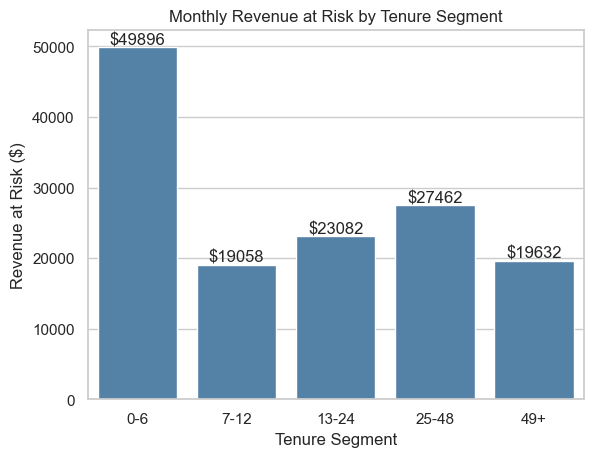

In [12]:
tenure_revenue = (customer[customer['Churn'] == 'Yes']
    .groupby('TenureGroup', observed=True, as_index=False)['MonthlyCharges']
    .sum()
    .rename(columns={'MonthlyCharges':'RevenueAtRisk'})
)

ax = sns.barplot(data=tenure_revenue,x='TenureGroup',y='RevenueAtRisk',color='steelblue')

ax.set_title('Monthly Revenue at Risk by Tenure Segment')
ax.set_xlabel('Tenure Segment')
ax.set_ylabel('Revenue at Risk ($)')

for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f')

plt.show()

- Customers within their first 0–6 months contribute the highest monthly revenue loss at approximately 49.9K. Combined with their high churn rate, newly acquired customers represent both a major churn risk and financial retention opportunity

# Churn Rate by Online Security / Tech Support Combination

C:\Users\PAVANA HEBBAR\AppData\Local\Temp\ipykernel_1920\3545152316.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=service_churn,x='Security_Support_Segment',y='ChurnRate',palette='viridis')


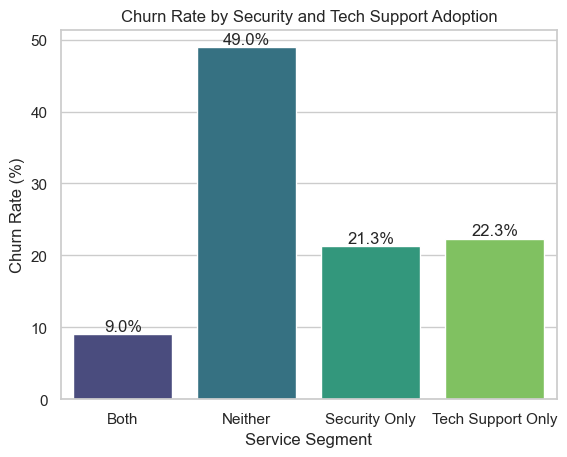

In [13]:
internet_customers = customer[customer['InternetService'] != 'No'].copy()

def create_security_support_segment(row):
    security = row['OnlineSecurity'] == 'Yes'
    support = row['TechSupport'] == 'Yes'

    if not security and not support:
        return 'Neither'
    elif security and not support:
        return 'Security Only'
    elif not security and support:
        return 'Tech Support Only'
    else:
        return 'Both'

internet_customers['Security_Support_Segment'] = internet_customers.apply(create_security_support_segment,axis=1)

service_churn = (internet_customers.groupby('Security_Support_Segment')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index(name='ChurnRate'))

ax = sns.barplot(data=service_churn,x='Security_Support_Segment',y='ChurnRate',palette='viridis')

ax.set_title('Churn Rate by Security and Tech Support Adoption')
ax.set_xlabel('Service Segment')
ax.set_ylabel('Churn Rate (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

- Internet customers with neither Online Security nor Tech Support have a 49.0% churn rate, compared with only 9.0% among customers using both services. This strong association suggests that customers without these services are an important segment for engagement and service-bundling initiatives

# Churn Rate by Payment Method and Paperless Billing

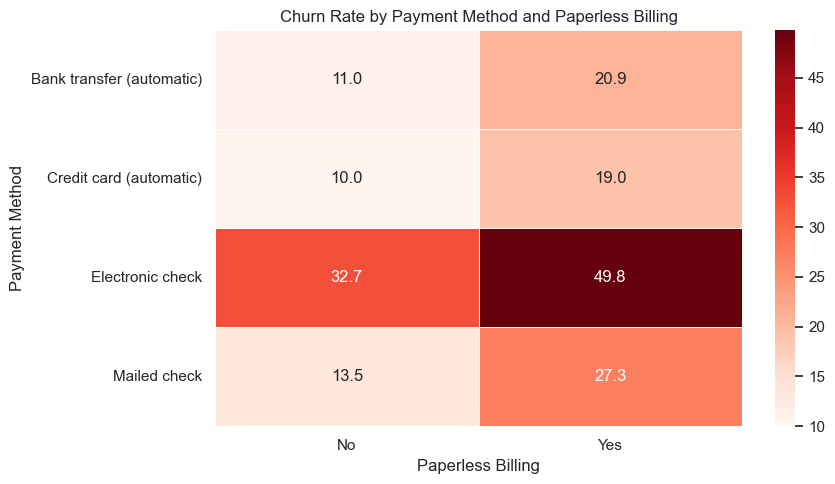

In [14]:
billing_churn = (
    customer.groupby(
        ['PaymentMethod', 'PaperlessBilling']
    )['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .unstack()
)

plt.figure(figsize=(9, 5))

sns.heatmap(billing_churn,annot=True,fmt='.1f',cmap='Reds',linewidths=0.5)

plt.title('Churn Rate by Payment Method and Paperless Billing')
plt.xlabel('Paperless Billing')
plt.ylabel('Payment Method')

plt.tight_layout()
plt.show()

- Customers using Electronic Check with Paperless Billing have the highest churn rate at 49.8%, while automatic payment customers without paperless billing have churn rates of around 10–11%. Electronic Check customers therefore represent a particularly high-risk billing segment

# Churn Rate by Monthly Charge Band

In [15]:
customer['MonthlyChargeBand'] = pd.qcut(
    customer['MonthlyCharges'],
    q=4,
    labels=['Low Charges','Medium-Low Charges','Medium-High Charges','High Charges'])

charge_band_summary = (customer.groupby('MonthlyChargeBand', observed=True)
    .agg(Customers=('MonthlyCharges', 'count'),MinCharge=('MonthlyCharges', 'min'),MaxCharge=('MonthlyCharges', 'max')).reset_index())

charge_band_summary

,MonthlyChargeBand,Customers,MinCharge,MaxCharge
0,Low Charges,1762,18.25,35.50
1,Medium-Low Charges,1766,35.55,70.35
2,Medium-High Charges,1757,70.40,89.85
3,High Charges,1758,89.90,118.75


C:\Users\PAVANA HEBBAR\AppData\Local\Temp\ipykernel_1920\3918743948.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=charge_churn,x='MonthlyChargeBand',y='ChurnRate',palette='coolwarm')


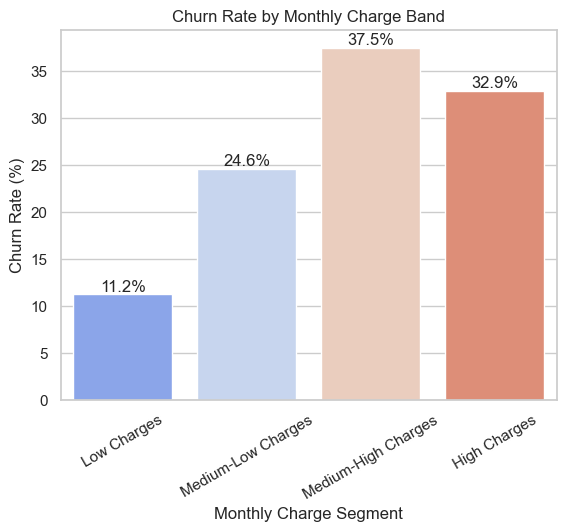

In [16]:
charge_churn = (customer.groupby('MonthlyChargeBand', observed=True)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='ChurnRate'))

ax = sns.barplot(data=charge_churn,x='MonthlyChargeBand',y='ChurnRate',palette='coolwarm')

ax.set_title('Churn Rate by Monthly Charge Band')
ax.set_xlabel('Monthly Charge Segment')
ax.set_ylabel('Churn Rate (%)')

plt.xticks(rotation=30)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

- Churn increases with monthly charges, from 11.2% among low-charge customers to 37.5% among high-charge customers. Higher-paying customers therefore show substantially greater churn risk and warrant greater retention attention

# Customer Churn Risk Matrix: Tenure × Monthly Charges

In [17]:
churn_matrix = (customer.groupby(['MonthlyChargeBand', 'TenureGroup'],observed=True)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .unstack()
)

churn_matrix

TenureGroup,0-6,7-12,13-24,25-48,49+
MonthlyChargeBand,,,,,
Low Charges,29.490022,12.935323,5.797101,4.438642,1.330377
Medium-Low Charges,52.495010,21.674877,22.101449,11.052632,5.911330
Medium-High Charges,72.127139,54.228856,40.287770,29.123711,6.237006
High Charges,77.500000,74.000000,54.123711,34.537246,16.981132


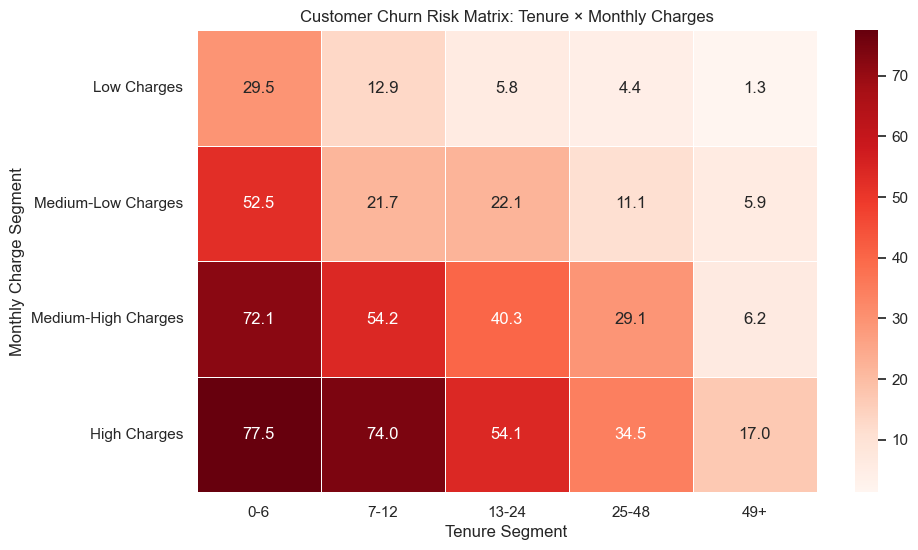

In [18]:
plt.figure(figsize=(10,6))

sns.heatmap(churn_matrix,annot=True,fmt='.1f',cmap='Reds',linewidths=0.5)

plt.title('Customer Churn Risk Matrix: Tenure × Monthly Charges')
plt.xlabel('Tenure Segment')
plt.ylabel('Monthly Charge Segment')

plt.show()

- The highest churn risk is concentrated among new, high-paying customers. High-charge customers with 0–6 months tenure have 77.5% churn, compared with just 1.3% for low-charge customers with 49+ months tenure, making short-tenure, high-charge customers the most vulnerable segment.

# Retention opportunity

In [19]:
segment_summary = (
    customer.groupby(['Contract', 'MonthlyChargeBand'],observed=True).agg(
        Customers=('customerID', 'count'),
        ChurnRate=('Churn', lambda x: (x == 'Yes').mean() * 100),
        RevenueAtRisk=(
            'MonthlyCharges',
            lambda x: x[
                customer.loc[x.index, 'Churn'] == 'Yes'
            ].sum()
        )
    )
    .reset_index()
)

segment_summary

,Contract,MonthlyChargeBand,Customers,ChurnRate,RevenueAtRisk
0,Month-to-month,Low Charges,723,25.034578,4379.10
1,Month-to-month,Medium-Low Charges,1109,35.617674,21716.20
2,Month-to-month,Medium-High Charges,1173,53.282182,50143.70
3,Month-to-month,High Charges,870,52.183908,44608.10
4,One year,Low Charges,394,3.045685,282.60
5,One year,Medium-Low Charges,371,8.625337,1855.25
6,One year,Medium-High Charges,262,11.068702,2343.05
7,One year,High Charges,446,20.852018,9637.55
8,Two year,Low Charges,645,0.775194,113.50
9,Two year,Medium-Low Charges,286,2.447552,398.80


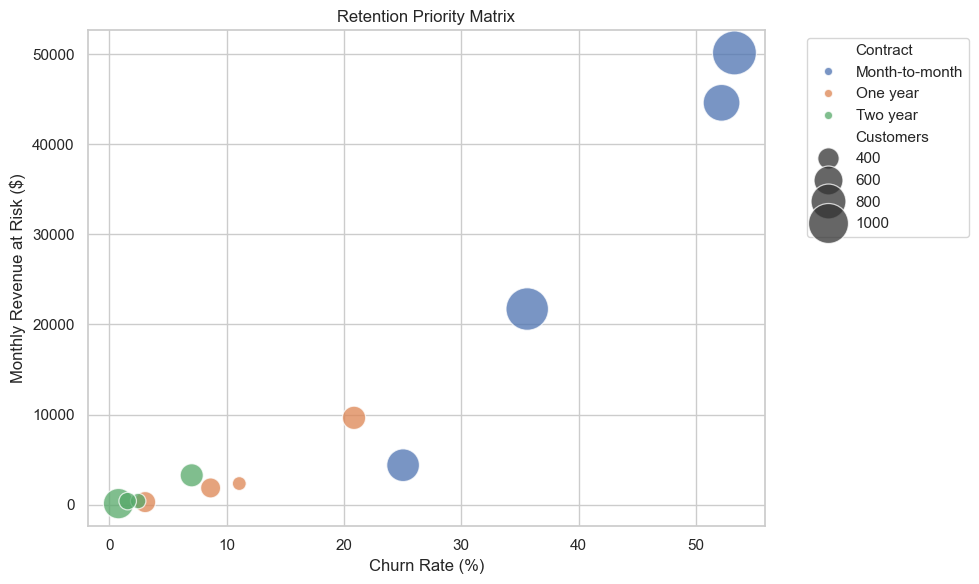

In [20]:
plt.figure(figsize=(10, 6))

ax = sns.scatterplot(data=segment_summary,x='ChurnRate',y='RevenueAtRisk',size='Customers',hue='Contract',sizes=(100, 1000),alpha=0.75)

plt.title('Retention Priority Matrix')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Monthly Revenue at Risk ($)')

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

- Medium-High and High-charge month-to-month customers are the highest retention priorities, combining churn rates above 52% with approximately $94.8K in combined monthly revenue exposure. Retention initiatives should therefore prioritize these high-value, high-risk customer segments

# Final key insights

- Churn is heavily concentrated among month-to-month and newly acquired customers. Month-to-month customers have a 42.7% churn rate, while customers within their first 0–6 months reach 52.9%, making early-lifecycle engagement and contract conversion key retention opportunities.
- Customer churn has a significant financial impact, accounting for approximately 139.1K in monthly recurring charges lost, with Fiber Optic customers contributing around 114.3K of this amount.
- Service adoption and billing behavior identify important churn-risk segments. Internet customers with neither Online Security nor Tech Support have 49.0% churn, compared with only 9.0% among customers using both, while Electronic Check with Paperless Billing customers show 49.8% churn.
- The highest churn risk occurs among new, high-paying customers. High-charge customers within their first 0–6 months have a 77.5% churn rate, showing that the combination of short tenure and high monthly charges is a critical risk profile.
- Higher-paying month-to-month customers represent the strongest retention priority. Medium-High and High-charge month-to-month segments together account for approximately $94.8K in monthly churn-related revenue, indicating that targeted retention offers, stronger early engagement, service bundling, and long-term contract incentives should focus primarily on these high-risk, high-value customers.